In [4]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [5]:
wd = 0.6366896896896898
t_max = 500
tlist = np.linspace(0, t_max, 1000)

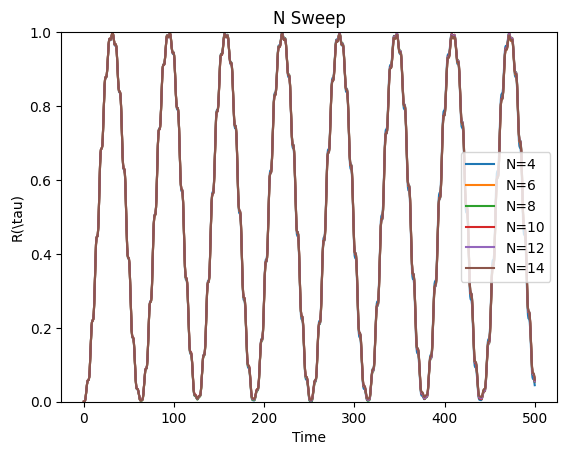

In [6]:
args = {"A": 0.1, "omega": wd}

for N in [4, 6, 8, 10, 12, 14]:
    H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
    H1, driveWeights = get_scar_H1(N, basisList)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    plt.plot(tlist, Rtau_scar, label=f"N={N}")

plt.title(f"N Sweep")
plt.xlabel("Time")
plt.ylabel(r"R(\tau)")
plt.legend()
plt.ylim(0, 1)
plt.show()